# Práctico 2 — Análisis Exploratorio y Curación de Datos
## DiploDatos 2026 · Ciencia de Datos Aplicada al Fútbol

**Objetivos de aprendizaje**
- Realizar un EDA riguroso sobre datos de eventos de fútbol
- Detectar y tratar problemas de calidad: valores faltantes, outliers, inconsistencias
- Convertir eventos de Wyscout al formato SPADL (Soccer Player Action Description Language)
- Construir features contextuales y posicionales para modelado
- Entender el sesgo de selección en datos deportivos

**Referencia clave**: Decroos et al. (2019) *Actions Speak Louder than Goals: Valuing Player Actions in Football*

---

### **Entregable 4/9/26**: 
- Notebook con EDA completo
- Reporte de decisiones de curación 
- PPT con donde se muestren los principales hallazgos encontrados en los dos primeros TPs.

---

In [1]:
import json
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import kstest, normaltest
import matplotlib.patches as mpatches
from matplotlib.colors import to_rgba
import plotly.express as px
import plotly.graph_objects as go
#from scipy.stats import gaussian_kde
from mplsoccer import Pitch, VerticalPitch, FontManager
from mplsoccer.utils import FontManager
import sys
import time
from pathlib import Path
from typing import List, Dict, Callable, Optional, Union
import pyarrow.parquet as pq
from io import BytesIO

# socceraction: librería oficial para SPADL
import socceraction.spadl as spadl
from socceraction.data.wyscout import WyscoutLoader

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)

# Configuración visual
PALETTE = sns.color_palette('Set2')
sns.set_theme(style='whitegrid', palette='Set2', font_scale=1.1)

# -- CONFIGURACION DE RUTAS --
DATA_DIR = Path('../data')
DATASET_DIR = DATA_DIR / 'events'
print(f'Data dir: {DATA_DIR}')
print(f'Dataset dir: {DATASET_DIR}')
print('✓ Librerías importadas correctamente')

Data dir: ../data
Dataset dir: ../data/events
✓ Librerías importadas correctamente


## 1. Carga completa del dataset multliga

En este práctico trabajamos con **todas las ligas** para tener una base más robusta.

In [2]:
#La siguiente celda enumera las competiciones que se incluirán en el conjunto de datos.
#Descomente las competiciones que desee incluir en su conjunto de datos.

competitions = [
    'England',
#    'France',
#    'Germany',
    'Italy',
    'Spain',
#    'European Championship',
#  'World Cup'
]

### 1.1 Lectura Optimizada de eventos desde archivos Parquet

In [3]:
def load_events_parquet(
    parquet_path: Path, 
    columns: Optional[List[str]] = None, 
    filters: Optional[List[tuple]] = None
) -> pd.DataFrame:
    """
    Carga eventos desde un archivo Parquet de forma optimizada.
    
    Parametros
    ----------
    parquet_path : Path al archivo .parquet.
    columns : Subconjunto de columnas a leer (None = todas).
    filters : Lista de tuplas para filtrar antes de cargar.
              Ejemplo: [('eventName', '==', 'Shot')]
    """
    print(f'[INFO] Cargando {parquet_path.name}...')
    t0 = time.time()
    
    # Leer con pyarrow + pandas para mejor rendimiento y control de tipos
    df = pd.read_parquet(
        parquet_path, 
        columns=columns, 
        filters=filters, 
        engine='pyarrow'
    )
    
    elapsed = time.time() - t0
    print(f'[INFO] Cargado en {elapsed:.2f}s | Filas: {len(df):,} | Columnas: {len(df.columns)}')
    return df


In [4]:
dfs=[]
for competition in competitions:
    competition_name = competition.replace(' ', '_')
    file_events = f'events_{competition_name}.parquet'
    print(f"file: {file_events}")
    FILE_PATH=DATASET_DIR / file_events
    print(f"file path: {FILE_PATH}")
    #json_events = read_json_file(file_events)
    data = load_events_parquet(
                            FILE_PATH,
                            columns= ['eventId', 'subEventName', 'tags', 'playerId', 'positions', 'matchId', 'eventName', 'teamId', 'matchPeriod', 'eventSec', 'subEventId', 'id']
                        )
    #df_all = pd.DataFrame(data)
    data['league'] = competition
    dfs.append(data)#df_all)
    print(f'  {competition}: {len(data):>8,} eventos')
    del data
df_all = pd.concat(dfs)
del dfs
print(f'\nTotal: {len(df_all):,} eventos | {df_all["league"].nunique()} ligas')

file: events_England.parquet
file path: ../data/events/events_England.parquet
[INFO] Cargando events_England.parquet...
[INFO] Cargado en 0.83s | Filas: 643,150 | Columnas: 12
  England:  643,150 eventos
file: events_Italy.parquet
file path: ../data/events/events_Italy.parquet
[INFO] Cargando events_Italy.parquet...
[INFO] Cargado en 0.47s | Filas: 647,372 | Columnas: 12
  Italy:  647,372 eventos
file: events_Spain.parquet
file path: ../data/events/events_Spain.parquet
[INFO] Cargando events_Spain.parquet...
[INFO] Cargado en 0.45s | Filas: 628,659 | Columnas: 12
  Spain:  628,659 eventos

Total: 1,919,181 eventos | 3 ligas


### 1.2 Lectura de archivos de partidos

In [5]:

def read_json_file(filename):
    with open(filename, 'rb') as json_file:
        return BytesIO(json_file.read()).getvalue().decode('unicode_escape')

def load_json(path: str) -> pd.DataFrame:
    print(path)
    data = pd.read_json(str(path))
    #data=read_json_file(path)
    return data#pd.read_json(data)


In [6]:
dfs_matches = []
for competition in competitions:
    competition_name = competition.replace(' ', '_')
    file_matches = f'matches/matches_{competition_name}.json'
    #print(f"file: {file_matches}")
    FILE_PATH=DATA_DIR / file_matches
    print(f"file path: {FILE_PATH}")
    #json_matches = read_json_file(FILE_PATH)
    data = load_json(FILE_PATH)#pd.read_json(json_matches)
    dfs_matches.append(data)
    del data
df_matches = pd.concat(dfs_matches)
del dfs_matches
df_matches.head(3)

file path: ../data/matches/matches_England.json
../data/matches/matches_England.json
file path: ../data/matches/matches_Italy.json
../data/matches/matches_Italy.json
file path: ../data/matches/matches_Spain.json
../data/matches/matches_Spain.json


,status,roundId,gameweek,teamsData,seasonId,dateutc,winner,venue,wyId,label,date,referees,duration,competitionId
0,Played,4405654,38,"{'1646': {'scoreET': 0, 'coachId': 8880, 'side...",181150,2018-05-13 14:00:00,1659,Turf Moor,2500089,"Burnley - AFC Bournemouth, 1 - 2","May 13, 2018 at 4:00:00 PM GMT+2","[{'refereeId': 385705, 'role': 'referee'}, {'r...",Regular,364
1,Played,4405654,38,"{'1628': {'scoreET': 0, 'coachId': 8357, 'side...",181150,2018-05-13 14:00:00,1628,Selhurst Park,2500090,"Crystal Palace - West Bromwich Albion, 2 - 0","May 13, 2018 at 4:00:00 PM GMT+2","[{'refereeId': 381851, 'role': 'referee'}, {'r...",Regular,364
2,Played,4405654,38,"{'1609': {'scoreET': 0, 'coachId': 7845, 'side...",181150,2018-05-13 14:00:00,1609,The John Smith's Stadium,2500091,"Huddersfield Town - Arsenal, 0 - 1","May 13, 2018 at 4:00:00 PM GMT+2","[{'refereeId': 384965, 'role': 'referee'}, {'r...",Regular,364


### 1.3 Lectura de archivos de jugadores y equipos

In [7]:
# Carga de metadata de equipos
df_teams = load_json(DATA_DIR / 'teams.json')
df_teams

../data/teams.json


,city,name,wyId,officialName,area,type
0,Newcastle upon Tyne,Newcastle United,1613,Newcastle United FC,"{'name': 'England', 'id': '0', 'alpha3code': '...",club
1,Vigo,Celta de Vigo,692,Real Club Celta de Vigo,"{'name': 'Spain', 'id': '724', 'alpha3code': '...",club
2,Barcelona,Espanyol,691,Reial Club Deportiu Espanyol,"{'name': 'Spain', 'id': '724', 'alpha3code': '...",club
3,Vitoria-Gasteiz,Deportivo Alav\u00e9s,696,Deportivo Alav\u00e9s,"{'name': 'Spain', 'id': '724', 'alpha3code': '...",club
4,Valencia,Levante,695,Levante UD,"{'name': 'Spain', 'id': '724', 'alpha3code': '...",club
...,...,...,...,...,...,...
137,Las Rozas,Spain,1598,Spain,"{'name': 'Spain', 'id': 724, 'alpha3code': 'ES...",national
138,Beograd,Serbia,17322,Serbia,"{'name': 'Serbia', 'id': 688, 'alpha3code': 'S...",national
139,Bern,Switzerland,6697,Switzerland,"{'name': 'Switzerland', 'id': 756, 'alpha3code...",national
140,Warszawa,Poland,13869,Poland,"{'name': 'Poland', 'id': 616, 'alpha3code': 'P...",national


In [8]:
# Carga de metadata de jugadores
df_players = load_json(DATA_DIR / 'players.json')
df_players.head(3)

../data/players.json


,passportArea,weight,firstName,middleName,lastName,currentTeamId,birthDate,height,role,birthArea,wyId,foot,shortName,currentNationalTeamId
0,"{'name': 'Turkey', 'id': '792', 'alpha3code': ...",78,Harun,,Tekin,4502,1989-06-17,187,"{'code2': 'GK', 'code3': 'GKP', 'name': 'Goalk...","{'name': 'Turkey', 'id': '792', 'alpha3code': ...",32777,right,H. Tekin,4687
1,"{'name': 'Senegal', 'id': '686', 'alpha3code':...",73,Malang,,Sarr,3775,1999-01-23,182,"{'code2': 'DF', 'code3': 'DEF', 'name': 'Defen...","{'name': 'France', 'id': '250', 'alpha3code': ...",393228,left,M. Sarr,4423
2,"{'name': 'France', 'id': '250', 'alpha3code': ...",72,Over,,Mandanda,3772,1998-10-26,176,"{'code2': 'GK', 'code3': 'GKP', 'name': 'Goalk...","{'name': 'France', 'id': '250', 'alpha3code': ...",393230,,O. Mandanda,null


## 2. EDA — Análisis Exploratorio de Datos

### 2.1 Estructura y tipos de datos

In [9]:
print('=== INFO GENERAL DEL DATASET ===')
print(f'Shape: {df_all.shape}')
print(f'Memoria: {df_all.memory_usage(deep=True).sum() / 1e6:.1f} MB')
print()
print('Tipos de datos:')
print(df_all.dtypes)

=== INFO GENERAL DEL DATASET ===
Shape: (1919181, 13)
Memoria: 698.7 MB

Tipos de datos:
eventId           int64
subEventName        str
tags             object
playerId          int64
positions        object
matchId           int64
eventName           str
teamId            int64
matchPeriod         str
eventSec        float64
subEventId          str
id                int64
league              str
dtype: object


### 2.2 Análisis de valores faltantes

In [10]:
def analyze_missing(df):
    """Genera reporte completo de valores faltantes."""
    missing = df.isnull().sum()
    pct = (missing / len(df) * 100).round(2)
    report = pd.DataFrame({
        'missing_count': missing,
        'missing_pct': pct,
        'dtype': df.dtypes
    }).sort_values('missing_pct', ascending=False)
    return report[report['missing_count'] > 0]

missing_report = analyze_missing(df_all)
print('Columnas con valores faltantes:')
print(missing_report.to_string())

Columnas con valores faltantes:
Empty DataFrame
Columns: [missing_count, missing_pct, dtype]
Index: []


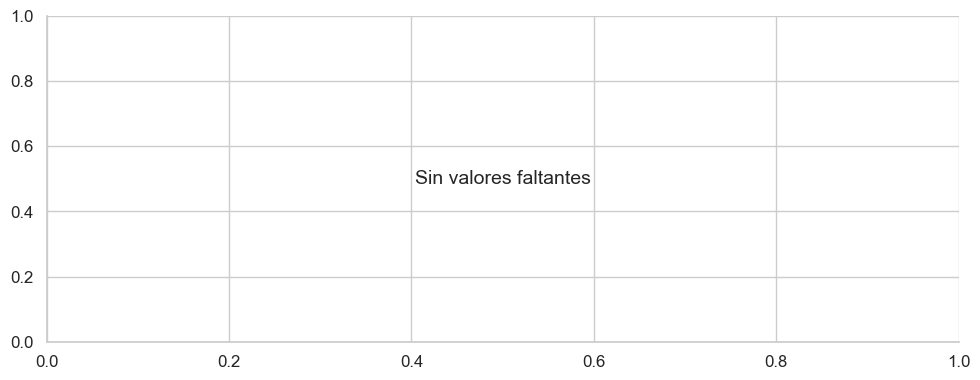

In [11]:
# Visualización del patrón de missings
fig, ax = plt.subplots(figsize=(10, 4))
cols_with_missing = missing_report[missing_report['missing_pct'] > 0].index
if len(cols_with_missing) > 0:
    missing_report[missing_report['missing_pct'] > 0]['missing_pct'].sort_values().plot(
        kind='barh', ax=ax, color='#378ADD'
    )
    ax.set_xlabel('% de valores faltantes')
    ax.set_title('Análisis de valores faltantes por columna')
    ax.axvline(x=5, color='orange', linestyle='--', label='Umbral 5%')
    ax.axvline(x=20, color='red', linestyle='--', label='Umbral 20%')
    ax.legend()
else:
    ax.text(0.5, 0.5, 'Sin valores faltantes', ha='center', va='center', fontsize=14)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

### 2.3 Extracción y análisis de coordenadas.

In [12]:
def parse_positions(pos_list):
    """Extrae coordenadas x,y del campo (0-100) desde el campo 'positions'."""
    if isinstance(pos_list, list) and len(pos_list) >= 1:
        return pos_list[0].get('x', np.nan), pos_list[0].get('y', np.nan)
    return np.nan, np.nan

def parse_end_positions(pos_list):
    """Extrae posición final de la acción."""
    if isinstance(pos_list, list) and len(pos_list) >= 2:
        return pos_list[1].get('x', np.nan), pos_list[1].get('y', np.nan)
    return np.nan, np.nan

def parse_tags(tag_list):
    """Extrae lista de IDs de tags."""
    if isinstance(tag_list.tolist(), list):
        return [t.get('id') for t in tag_list.tolist()]
    return []


In [13]:

# Aplicamos parseo vectorizado
df_all[['x', 'y']] = df_all['positions'].apply(
    lambda p: pd.Series(parse_positions(p.tolist()))
)
df_all[['end_x', 'end_y']] = df_all['positions'].apply(
    lambda p: pd.Series(parse_end_positions(p.tolist()))
)
df_all['tag_ids'] = df_all['tags'].apply(parse_tags)


#### Auditoría de coordenadas

In [14]:
print('=== AUDITORÍA DE COORDENADAS ===')
print(f'Eventos con x válido: {df_all["x"].notna().sum():,} ({df_all["x"].notna().mean():.1%})')
print(f'Eventos con y válido: {df_all["y"].notna().sum():,} ({df_all["y"].notna().mean():.1%})')
print(f'Rango x: [{df_all["x"].min():.1f}, {df_all["x"].max():.1f}]')
print(f'Rango y: [{df_all["y"].min():.1f}, {df_all["y"].max():.1f}]')

# Eventos fuera de rango (0-100)
out_of_bounds = df_all[
    (df_all['x'].notna()) & 
    ((df_all['x'] < 0) | (df_all['x'] > 100) | (df_all['y'] < 0) | (df_all['y'] > 100))
]
print(f'\nEventos con coordenadas fuera de rango: {len(out_of_bounds)} ({len(out_of_bounds)/len(df_all):.2%})')

=== AUDITORÍA DE COORDENADAS ===
Eventos con x válido: 1,919,181 (100.0%)
Eventos con y válido: 1,919,181 (100.0%)
Rango x: [-1.0, 100.0]
Rango y: [0.0, 100.0]

Eventos con coordenadas fuera de rango: 1 (0.00%)


In [15]:
out_of_bounds

,eventId,subEventName,tags,playerId,positions,matchId,eventName,teamId,matchPeriod,eventSec,subEventId,id,league,x,y,end_x,end_y,tag_ids
140843,7,Touch,[],166534,"[{'x': -1, 'y': 47}, {'x': 69, 'y': 12}]",2576042,Others on the ball,3162,2H,2753.1903,72,198907641,Italy,-1,47,69.0000,12.0000,[]


##### Se detecta un único caso en la liga Italiana, y siendo un evento "Others on the ball" y "Touch" en subEventName, en el segundo tiempo (45.89 minutos), la decisión es eliminar el registro. Dcoumentación de la decisión:

Problema: coordenada x=-1 fuera del rango válido (0-100).
Registros afectados: 1 de 1.919.181 (0.00005%).
Decisión de curación: eliminar. Dado que es "Others on the ball" (acción sin relevancia táctica clara).
Alternativa considerada: imputar con la mediana de x para ese tipo de evento, pero con un solo caso no vale la pena.

#### Distribución espacial de los eventos — heatmap 2D

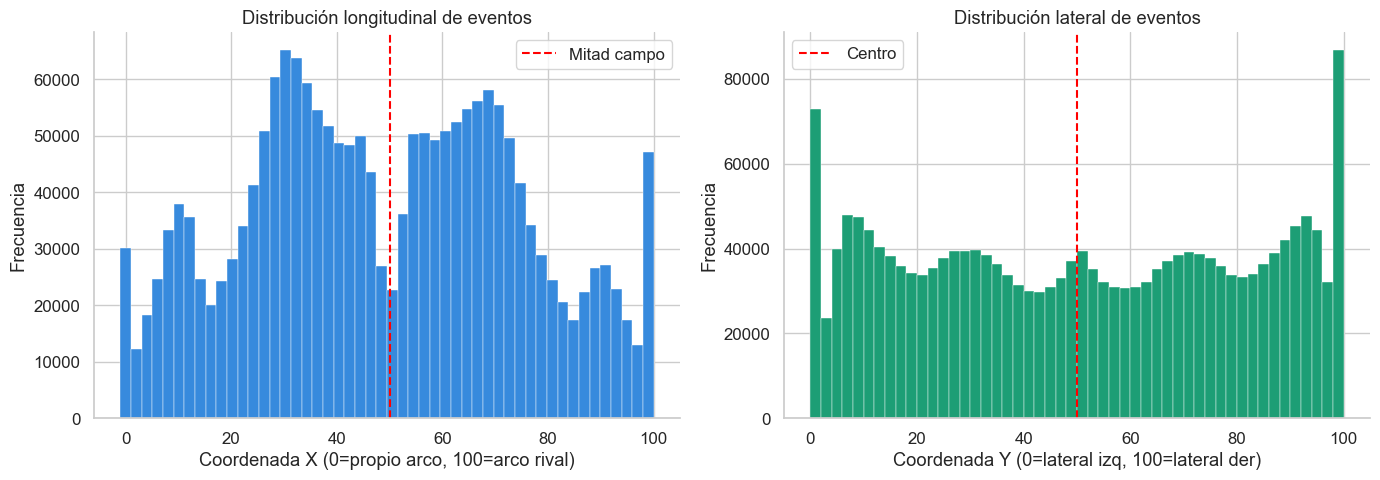

In [16]:

df_valid = df_all.dropna(subset=['x','y'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribución x
axes[0].hist(df_valid['x'], bins=50, color='#378ADD', edgecolor='white', linewidth=0.3)
axes[0].set_xlabel('Coordenada X (0=propio arco, 100=arco rival)')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución longitudinal de eventos')
axes[0].axvline(50, color='red', linestyle='--', label='Mitad campo')
axes[0].legend()
axes[0].spines[['top','right']].set_visible(False)

# Distribución y
axes[1].hist(df_valid['y'], bins=50, color='#1D9E75', edgecolor='white', linewidth=0.3)
axes[1].set_xlabel('Coordenada Y (0=lateral izq, 100=lateral der)')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Distribución lateral de eventos')
axes[1].axvline(50, color='red', linestyle='--', label='Centro')
axes[1].legend()
axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.show()

## Análisis parciales de los resultados de distribución de eventos. 

Existen algunos resultados coherentes: los picos en X entre 30-40; y entre 55-75 aproximadamente son consistentes con las zonas de gestación en la mitad propia/presión del rival y con la fase de ataque y defensa del rival. El mediocampo es una zona de transición. Si llama un poco más la atención las colas cargadas en X=0 y X=100, que si bien pueden ser consistentes con saques de arco, corners, goles, vale la pena examinar más.
Si es más llamativa la concentración en Y=0 e Y=100, que si bien pueden representar saques de banda y corners, la concentración es notable y conviene analizarla. 

### ¿Son placeholders sistemáticos de Wyscout para eventos sin coordenada precisa?

In [17]:
# Ver los eventos en cada borde

for val, eje in [(0, 'x'), (100, 'x'), (0, 'y'), (100, 'y')]:
    mask = df_all[eje] == val
    print(f"\n=== {eje}={val} — {mask.sum():,} eventos ({mask.mean():.1%}) ===")
    print(df_all[mask]['eventName'].value_counts().head(10))


=== x=0 — 26,522 eventos (1.4%) ===
eventName
Interruption               11729
Free Kick                   8423
Save attempt                4615
Goalkeeper leaving line     1608
Others on the ball            73
Pass                          49
Duel                          24
Foul                           1
Name: count, dtype: int64

=== x=100 — 39,941 eventos (2.1%) ===
eventName
Free Kick                  21720
Interruption               10350
Save attempt                5705
Goalkeeper leaving line     2026
Pass                          93
Duel                          23
Others on the ball            12
Foul                           6
Shot                           4
Offside                        2
Name: count, dtype: int64

=== y=0 — 69,295 eventos (3.6%) ===
eventName
Free Kick                  37373
Interruption               24977
Save attempt                4615
Goalkeeper leaving line     1608
Pass                         533
Others on the ball            98
Duel         

In [18]:
# Ver si hay diferencias en la concentración de eventos en los bordes, por ligas

for liga in df_all['league'].unique():
    sub = df_all[df_all['league'] == liga]
    borde_y = ((sub['y'] == 0) | (sub['y'] == 100)).mean()
    borde_x = ((sub['x'] == 0) | (sub['x'] == 100)).mean()
    print(f"{liga}: borde_y={borde_y:.1%}, borde_x={borde_x:.1%}")

England: borde_y=7.6%, borde_x=3.4%
Italy: borde_y=7.4%, borde_x=3.5%
Spain: borde_y=7.4%, borde_x=3.4%


#### Conclusiones 

Los 2 ejercicios realizados son consistentes y coherentes: 

1. Los eventos en los bordes son interrupciones (salidas del campo), freekicks que concentra saques laterales, corners y tiros libres propiamente dichos) o salvadas del arquero entre los más frecuentes.
2. Comparación entre ligas: la distribución es identica, por lo que no parecieran placeholders particulares según la liga.

#### Conclusión general: No se trata de eventos anómalos que deban eliminarse o imputarse. Decisión final: conservación de eventos en coordenadas extremas (x=0, x=100, y=0, y=100).

### 2.4 Detección de outliers y anomalías en los datos
En eventos de fútbol, los valores atípicos suelen originarse por:
1. **Errores de registro o medición:** Coordenadas fuera de escala o valores temporales anómalos (detectables con métodos estadísticos como IQR y Z-Score).
2. **Partidos incompletos o truncados:** Partidos con una cantidad inusualmente baja o excesiva de eventos registrados respecto a la media.
3. **Casos reales extremos (outliers válidos):** Jugadas excepcionales que no deben eliminarse porque forman parte del juego real.

In [18]:
def detect_outliers_iqr(series: pd.Series, factor: float = 1.5) -> pd.Series:
    """Detecta outliers usando el criterio IQR."""
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - factor * IQR
    upper = Q3 + factor * IQR
    return (series < lower) | (series > upper)

def detect_outliers_zscore(series: pd.Series, threshold: float = 3.0) -> pd.Series:
    """Detecta outliers usando Z-score nativo de pandas."""
    mean = series.mean()
    std = series.std(ddof=0)
    if std == 0 or pd.isna(std):
        return pd.Series(False, index=series.index)
    z = ((series - mean) / std).abs()
    return (z > threshold).fillna(False)


In [19]:
# Si ya extrajiste x e y de 'positions':
for col in ['x', 'y']:
    if col in df_all.columns:
        series = df_all[col].dropna()
        iqr_outliers = detect_outliers_iqr(series)
        z_outliers   = detect_outliers_zscore(series)
        print(f'{col}: IQR outliers={iqr_outliers.sum():,} | Z-score outliers={z_outliers.sum():,}')

print('\n=== ANÁLISIS DE PERÍODOS ===')
if 'matchPeriod' in df_all.columns and 'eventSec' in df_all.columns:
    print(df_all.groupby('matchPeriod')['eventSec'].describe())


x: IQR outliers=0 | Z-score outliers=0
y: IQR outliers=0 | Z-score outliers=0

=== ANÁLISIS DE PERÍODOS ===
                  count      mean      std    min      25%       50%  \
matchPeriod                                                            
1H          314493.0000 1337.7612 801.2280 0.0355 637.9151 1321.4727   
2H          314166.0000 1418.3142 850.8446 0.0689 670.3297 1406.1518   

                  75%       max  
matchPeriod                      
1H          2031.8526 3003.0694  
2H          2154.5694 3217.0262  


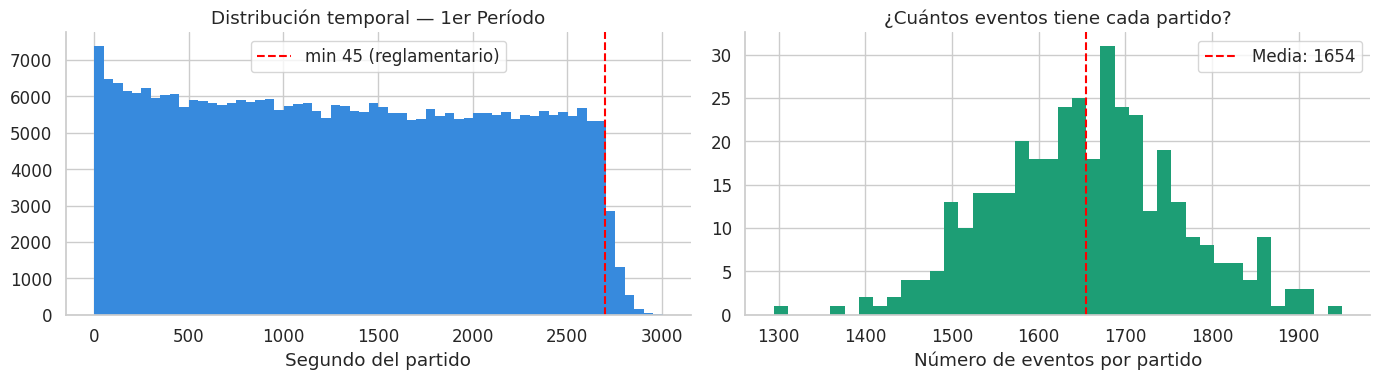

Partidos potencialmente problemáticos: 8


In [20]:
# Análisis de tiempos de eventos
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Distribución de segundos en el primer período
p1 = df_all[df_all['matchPeriod'] == '1H']['eventSec'].clip(0, 6000)
axes[0].hist(p1, bins=60, color='#378ADD', edgecolor='none')
axes[0].set_xlabel('Segundo del partido')
axes[0].set_title('Distribución temporal — 1er Período')
axes[0].axvline(45*60, color='red', linestyle='--', label='min 45 (reglamentario)')
axes[0].legend()
axes[0].spines[['top','right']].set_visible(False)

# Número de eventos por partido — distribución
events_per_match = df_all.groupby('matchId').size()
axes[1].hist(events_per_match, bins=40, color='#1D9E75', edgecolor='none')
axes[1].set_xlabel('Número de eventos por partido')
axes[1].set_title('¿Cuántos eventos tiene cada partido?')
axes[1].axvline(events_per_match.mean(), color='red', linestyle='--', 
                label=f'Media: {events_per_match.mean():.0f}')
axes[1].legend()
axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.show()

# Partidos con muy pocos o muchos eventos (posibles problemas de datos)
q01 = events_per_match.quantile(0.01)
q99 = events_per_match.quantile(0.99)
problematic = events_per_match[(events_per_match < q01) | (events_per_match > q99)]
print(f'Partidos potencialmente problemáticos: {len(problematic)}')

### 2.5 Análisis de sesgo en los datos

Los datos deportivos tienen sesgos importantes que debemos documentar:
- Sesgo de equipo: los equipos más populares tienen más cobertura
- Sesgo de posición: los jugadores ofensivos tienen más eventos registrados
- Sesgo de resultado: se registran más eventos cerca de los goles

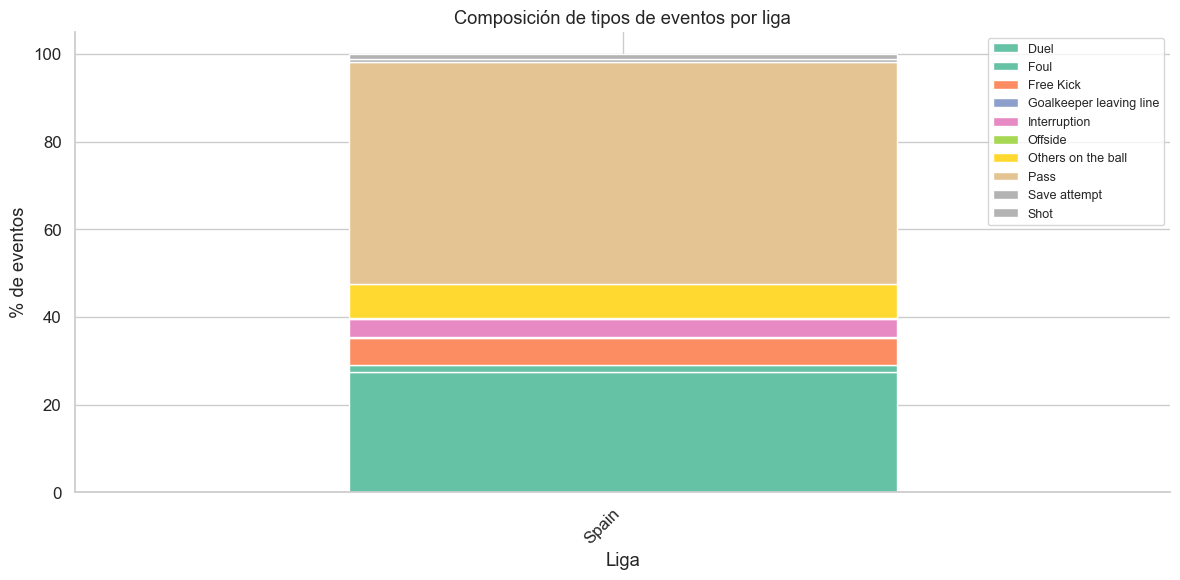


¿Son comparables los datos entre ligas? ¿Hay diferencias en la anotación?


In [20]:
# Distribución de eventos por tipo — ¿hay sesgo hacia eventos ofensivos?
event_dist = df_all.groupby(['league', 'eventName']).size().unstack(fill_value=0)
event_dist_pct = event_dist.div(event_dist.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(12, 6))
event_dist_pct.plot(kind='bar', stacked=True, ax=ax, colormap='Set2')
ax.set_xlabel('Liga')
ax.set_ylabel('% de eventos')
ax.set_title('Composición de tipos de eventos por liga')
ax.legend(loc='upper right', fontsize=9)
ax.spines[['top','right']].set_visible(False)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print('\n¿Son comparables los datos entre ligas? ¿Hay diferencias en la anotación?')

## 3. Conversión a SPADL

SPADL (Soccer Player Action Description Language) es el formato estándar propuesto por
Decroos et al. (2019). Representa cada acción como un vector con:
- `game_id`, `period_id`, `time_seconds`: identificación temporal
- `team_id`, `player_id`: actores
- `start_x`, `start_y`, `end_x`, `end_y`: posiciones
- `action_type_id`: tipo de acción (18 tipos estandarizados)
- `bodypart_id`: parte del cuerpo usada
- `result_id`: resultado (exitoso/fallido/gol/etc)

In [22]:
# 1. Extraer los IDs únicos que realmente existen en tus eventos filtrados
# (Asegúrate de que los nombres de las columnas coincidan con los de tu df_all)
equipos_validos = df_all['teamId'].unique()
jugadores_validos = df_all['playerId'].unique()

# Opcional: Eliminar el ID '0' si existe (Wyscout usa 0 para eventos sin un jugador/equipo específico)
jugadores_validos = [pid for pid in jugadores_validos if pid != 0]

# 2. Filtrar df_teams y df_players
# (En los datos crudos de Wyscout, la columna de ID para equipos y jugadores suele ser 'wyId')
df_teams_filtrado = df_teams[df_teams['wyId'].isin(equipos_validos)]
df_players_filtrado = df_players[df_players['wyId'].isin(jugadores_validos)]

# 3. Agrupar los eventos por partido (como hicimos antes)
# (Revisa si en tu df_all la columna es 'matchId' o 'match_id')
events_dict = {match_id: df for match_id, df in df_all.groupby('matchId')}

# 4. Armar el diccionario con los datos ya limpios y filtrados
datos_wyscout = {
    "matches": df_matches,  # Este ya lo tenías filtrado
    "players": df_players_filtrado, # <-- ¡Usamos el filtrado!
    "teams": df_teams_filtrado,     # <-- ¡Usamos el filtrado!
    "events": events_dict
}


In [23]:
from socceraction.spadl.config import actiontypes, bodyparts, results

In [24]:
from wyscout import (
    convert_games, 
    convert_players, 
    convert_teams, 
    get_player_games, 
    convert_actions
)

In [26]:
import tqdm

def convert_to_spadl_memory(wyscout_data, actiontypes, bodyparts, results):
    """
    Convierte datos de Wyscout a SPADL usando DataFrames en memoria.
    
    Parámetros:
    wyscout_data: dict que contiene las claves 'matches', 'players', 'teams' 
                  y un diccionario de 'events' agrupado por ID de partido.
    """
    # Diccionario que guardará todos nuestros DataFrames convertidos
    spadl_data = {}

    print("...Inserting actiontypes, bodyparts, results")
    spadl_data["actiontypes"] = pd.DataFrame(
        list(enumerate(actiontypes)), columns=["type_id", "type_name"]
    )
    spadl_data["bodyparts"] = pd.DataFrame(
        list(enumerate(bodyparts)), columns=["bodypart_id", "bodypart_name"]
    )
    spadl_data["results"] = pd.DataFrame(
        list(enumerate(results)), columns=["result_id", "result_name"]
    )

    print("...Converting matches, players, teams")
    # Nota: Asegúrate de tener importadas/definidas convert_games, convert_players, convert_teams
    matches = wyscout_data["matches"]
    games = convert_games(matches)
    
    spadl_data["games"] = games
    spadl_data["players"] = convert_players(wyscout_data["players"])
    spadl_data["teams"] = convert_teams(wyscout_data["teams"])

    print("...Generating player_games")
    player_games = []
    for match in tqdm.tqdm(list(matches.itertuples()), unit="game"):
        # Asume que guardaste los eventos en un diccionario donde la clave es el ID del partido
        events = wyscout_data["events"][match.wyId] 
        
        pg = get_player_games(match, events)
        player_games.append(pg)
        
    spadl_data["player_games"] = pd.concat(player_games)

    print("...Converting events to actions")
    spadl_data["actions"] = {} # Sub-diccionario para las acciones de cada partido
    
    for game in tqdm.tqdm(list(games.itertuples()), unit="game"):
        events = wyscout_data["events"][game.game_id]
        actions = convert_actions(events, game.home_team_id)
        
        # Guardamos las acciones en memoria, usando el ID del partido como clave
        spadl_data["actions"][game.game_id] = actions
        
    return spadl_data

In [27]:

# 5. Ejecutar la función
datos_spadl = convert_to_spadl_memory(datos_wyscout, actiontypes, bodyparts, results)

...Inserting actiontypes, bodyparts, results
...Converting matches, players, teams
...Generating player_games


  0%|          | 0/380 [00:00<?, ?game/s]

100%|██████████| 380/380 [00:00<00:00, 1225.09game/s]


...Converting events to actions


100%|██████████| 380/380 [01:42<00:00,  3.70game/s]


In [28]:
# Primero, puedes ver qué IDs de partidos están disponibles:
print(datos_spadl["actions"].keys())


dict_keys([2565922, 2565925, 2565919, 2565924, 2565927, 2565920, 2565921, 2565923, 2565926, 2565918, 2565917, 2565910, 2565912, 2565908, 2565909, 2565911, 2565913, 2565914, 2565915, 2565916, 2565882, 2565884, 2565900, 2565907, 2565898, 2565899, 2565906, 2565901, 2565902, 2565903, 2565904, 2565905, 2565893, 2565889, 2565890, 2565896, 2565892, 2565888, 2565891, 2565894, 2565897, 2565895, 2565879, 2565886, 2565885, 2565883, 2565880, 2565878, 2565881, 2565887, 2565869, 2565877, 2565868, 2565870, 2565876, 2565871, 2565875, 2565872, 2565874, 2565873, 2565867, 2565862, 2565860, 2565865, 2565863, 2565859, 2565861, 2565858, 2565866, 2565864, 2565848, 2565851, 2565854, 2565852, 2565855, 2565856, 2565853, 2565850, 2565857, 2565849, 2565841, 2565839, 2565844, 2565846, 2565840, 2565838, 2565845, 2565847, 2565842, 2565843, 2565836, 2565832, 2565834, 2565830, 2565831, 2565837, 2565828, 2565835, 2565833, 2565829, 2565822, 2565826, 2565821, 2565824, 2565823, 2565820, 2565825, 2565819, 2565818, 2565827,

In [30]:
# acciones del primer partido en df_matches
df_acciones_un_partido = datos_spadl["actions"][df_matches.iloc[0,8]]
df_acciones_un_partido.sample(5)


,game_id,period_id,time_seconds,team_id,player_id,start_x,start_y,end_x,end_y,bodypart_id,type_id,result_id
891,2565922.0000,2.0000,1855.2381,676.0000,222770.0000,35.7000,4.7600,NaN,NaN,0,0,1
309,2565922.0000,1.0000,1592.7423,676.0000,3341.0000,38.8500,18.3600,NaN,NaN,0,0,1
788,2565922.0000,2.0000,1349.1293,687.0000,3282.0000,73.5000,58.4800,NaN,NaN,0,0,0
364,2565922.0000,1.0000,1828.7487,676.0000,286390.0000,76.6500,21.7600,NaN,NaN,0,0,0
262,2565922.0000,1.0000,1277.9921,676.0000,3353.0000,74.5500,40.8000,NaN,NaN,0,0,0


Unificamos en un dataset las acciones de todos los partidos

In [31]:
# 1. Unificar todas las acciones en un solo DataFrame
df_actions = pd.concat(datos_spadl["actions"].values(), ignore_index=True)

# 2. Cruzar con los catálogos de tipos de acción, resultados y partes del cuerpo
df_actions = df_actions.merge(datos_spadl["actiontypes"], on="type_id", how="left")
df_actions = df_actions.merge(datos_spadl["results"], on="result_id", how="left")
df_actions = df_actions.merge(datos_spadl["bodyparts"], on="bodypart_id", how="left")


In [34]:
# 3. Cruzar con Jugadores y Equipos para añadir sus nombres
# (Asegúrate de que las columnas clave coincidan, habitualmente 'player_id' y 'team_id')
if "players" in datos_spadl:
    df_actions = df_actions.merge(
        datos_spadl["players"][["player_id", "short_name"]], 
        on="player_id", 
        how="left"
    )

if "teams" in datos_spadl:
    df_actions = df_actions.merge(
        datos_spadl["teams"][["team_id", "team_name"]], 
        on="team_id", 
        how="left"
    )


In [36]:
# 4. Eliminar decimales en todas las columnas que representan IDs
# Buscamos dinámicamente cualquier columna que termine en '_id' o empiece con 'id'
columnas_id = [col for col in df_actions.columns if col.endswith("_id") or col == "action_id"]

for col in columnas_id:
    # Usamos 'Int64' (con I mayúscula), el tipo entero de pandas que soporta valores nulos sin convertirlos en floats
    df_actions[col] = df_actions[col].astype("Int64")

# Ver el resultado final
df_actions.head()

,game_id,period_id,time_seconds,team_id,player_id,start_x,start_y,end_x,end_y,bodypart_id,type_id,result_id,type_name,result_name,bodypart_name,short_name,team_name
0,2565922,1,1.0054,687,3576,53.5500,34.6800,NaN,NaN,0,0,1,pass,success,foot,Juanmi,Real Sociedad de F\u00fatbol
1,2565922,1,4.1515,687,3828,66.1500,17.6800,NaN,NaN,0,0,1,pass,success,foot,Ra\u00fal Navas,Real Sociedad de F\u00fatbol
2,2565922,1,24.2546,676,7972,30.4500,66.6400,NaN,NaN,0,0,0,pass,fail,foot,L. Su\u00e1rez,FC Barcelona
3,2565922,1,25.3277,687,3676,33.6000,66.6400,NaN,NaN,0,0,1,pass,success,foot,Illarramendi,Real Sociedad de F\u00fatbol
4,2565922,1,26.0093,687,3576,29.4000,57.1200,NaN,NaN,0,0,1,pass,success,foot,Juanmi,Real Sociedad de F\u00fatbol


### 3.1 Análisis del dataset SPADL

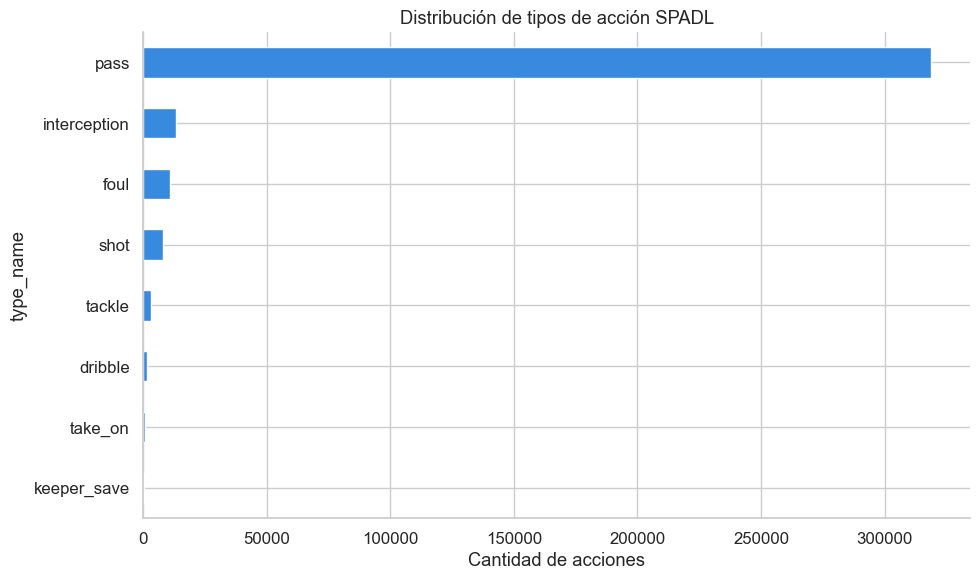


Tasa de éxito por tipo de acción:
type_name
dribble        1.0000
foul           1.0000
keeper_save    1.0000
pass           0.8284
interception   0.7368
tackle         0.5198
take_on        0.3963
shot           0.3710


In [37]:
# Distribución de tipos de acción SPADL
action_counts = df_actions['type_name'].value_counts()

fig, ax = plt.subplots(figsize=(10, 6))
action_counts.sort_values().plot(kind='barh', ax=ax, color='#378ADD')
ax.set_xlabel('Cantidad de acciones')
ax.set_title('Distribución de tipos de acción SPADL')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

# Estadísticas de resultado
print('\nTasa de éxito por tipo de acción:')
result_by_type = df_actions.groupby('type_name')['result_name'].apply(
    lambda x: (x == 'success').mean()
).sort_values(ascending=False)
print(result_by_type.to_string())

## 4. Feature Engineering

Construimos features que capturen el **contexto** de cada acción para el modelado posterior.

In [41]:
import socceraction.vaep.features as fs

# 1. Generamos los estados de juego (gamestates) para las últimas 3 acciones
# Nota: usa la variable donde tengas tus acciones SPADL ('actions' o 'df_spadl')
df_actions = actions if 'actions' in locals() else df_actions
gamestates = fs.gamestates(df_actions, nb_prev_actions=3)

# 2. Lista de funciones generadoras de features para VAEP
feat_functions = [
    fs.actiontype_onehot,
    fs.bodypart_onehot,
    fs.result_onehot,
    fs.goalscore,
    fs.startlocation,
    fs.endlocation,
    fs.movement,
    fs.space_delta,
    fs.startpolar,
    fs.endpolar,
    fs.team,
    fs.time,
    fs.time_delta,
]

# 3. Calculamos y concatenamos las features para los estados de juego
X_features = pd.concat([fn(gamestates) for fn in feat_functions], axis=1)

print(f'Features generados: {X_features.shape[1]} columnas')
print(f'Acciones procesadas: {X_features.shape[0]:,}')
print('\nPrimeras filas:')
display(X_features.head())


Features generados: 154 columnas
Acciones procesadas: 357,443

Primeras filas:


,actiontype_pass_a0,actiontype_cross_a0,actiontype_throw_in_a0,actiontype_freekick_crossed_a0,actiontype_freekick_short_a0,actiontype_corner_crossed_a0,actiontype_corner_short_a0,actiontype_take_on_a0,actiontype_foul_a0,actiontype_tackle_a0,actiontype_interception_a0,actiontype_shot_a0,actiontype_shot_penalty_a0,actiontype_shot_freekick_a0,actiontype_keeper_save_a0,actiontype_keeper_claim_a0,actiontype_keeper_punch_a0,actiontype_keeper_pick_up_a0,actiontype_clearance_a0,actiontype_bad_touch_a0,actiontype_non_action_a0,actiontype_dribble_a0,actiontype_goalkick_a0,actiontype_pass_a1,actiontype_cross_a1,...,start_dist_to_goal_a0,start_angle_to_goal_a0,start_dist_to_goal_a1,start_angle_to_goal_a1,start_dist_to_goal_a2,start_angle_to_goal_a2,end_dist_to_goal_a0,end_angle_to_goal_a0,end_dist_to_goal_a1,end_angle_to_goal_a1,end_dist_to_goal_a2,end_angle_to_goal_a2,team_1,team_2,period_id_a0,time_seconds_a0,time_seconds_overall_a0,period_id_a1,time_seconds_a1,time_seconds_overall_a1,period_id_a2,time_seconds_a2,time_seconds_overall_a2,time_delta_1,time_delta_2
0,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,...,51.4545,0.0132,51.4545,0.0132,51.4545,0.0132,NaN,0.0000,NaN,0.0000,NaN,0.0000,True,True,1,1.0054,1.0054,1,1.0054,1.0054,1,1.0054,1.0054,0.0000,0.0000
1,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,...,42.1386,0.3977,51.4545,0.0132,51.4545,0.0132,NaN,0.0000,NaN,0.0000,NaN,0.0000,True,True,1,4.1515,4.1515,1,1.0054,1.0054,1,1.0054,1.0054,3.1461,3.1461
2,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,...,81.3823,0.4127,42.1386,0.3977,51.4545,0.0132,NaN,0.0000,NaN,0.0000,NaN,0.0000,False,False,1,24.2546,24.2546,1,4.1515,4.1515,1,1.0054,1.0054,20.1030,23.2491
3,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,...,78.5069,0.4288,81.3823,0.4127,42.1386,0.3977,NaN,0.0000,NaN,0.0000,NaN,0.0000,False,True,1,25.3277,25.3277,1,24.2546,24.2546,1,4.1515,4.1515,1.0732,21.1762
4,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,...,79.0563,0.2968,78.5069,0.4288,81.3823,0.4127,NaN,0.0000,NaN,0.0000,NaN,0.0000,True,False,1,26.0093,26.0093,1,25.3277,25.3277,1,24.2546,24.2546,0.6816,1.7547


In [42]:
# Features personalizadas adicionales

def compute_custom_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Features adicionales que capturan contexto táctico.
    Estas features van más allá del paper original de VAEP.
    """
    df = df.copy()

    # 1. Zona del campo (5 zonas longitudinales)
    df['zone_x'] = pd.cut(
        df['start_x'],
        bins=[0, 20, 40, 60, 80, 105],
        labels=['defensa_propia', 'mediocampo_bajo', 'mediocampo', 'mediocampo_alto', 'ataque']
    )

    # 2. Zona lateral (3 carriles)
    df['carril'] = pd.cut(
        df['start_y'],
        bins=[0, 23, 45, 68],
        labels=['banda_izq', 'central', 'banda_der']
    )

    # 3. Distancia al arco rival
    df['dist_goal'] = np.sqrt(
        (105 - df['start_x'])**2 + (34 - df['start_y'])**2
    )

    # 4. Ángulo al arco (en grados)
    dx = 105 - df['start_x']
    dy = np.abs(34 - df['start_y'])
    df['angle_goal'] = np.degrees(np.arctan2(dy, dx + 1e-9))

    # 5. Velocidad de la acción (metros / segundo)
    df['dist_moved'] = np.sqrt(
        (df['end_x'] - df['start_x'])**2 + (df['end_y'] - df['start_y'])**2
    )

    # 6. Dirección de movimiento (hacia adelante/atrás/lateral)
    df['movement_dir'] = pd.cut(
        df['end_x'] - df['start_x'],
        bins=[-105, -5, 5, 105],
        labels=['hacia_atras', 'lateral', 'hacia_adelante']
    )

    # 7. ¿Acción en el último tercio?
    df['last_third'] = (df['start_x'] >= 70).astype(int)

    # 8. ¿Acción en el área grande? (aprox 16.5m del arco)
    df['in_box'] = (
        (df['start_x'] >= 88.5) &
        (df['start_y'] >= 13.84) & (df['start_y'] <= 54.16)
    ).astype(int)

    return df

df_spadl_fe = compute_custom_features(df_actions)
print('Features custom añadidas:')
new_cols = ['zone_x', 'carril', 'dist_goal', 'angle_goal', 'dist_moved', 
            'movement_dir', 'last_third', 'in_box']
print(df_spadl_fe[new_cols].describe())

Features custom añadidas:
        dist_goal  angle_goal  dist_moved  last_third      in_box
count 357252.0000 357252.0000  36413.0000 357443.0000 357443.0000
mean      55.7724     21.4829      3.8967      0.2858      0.0487
std       21.9621     16.0381      8.7065      0.4518      0.2152
min        0.0000      0.0000      0.0000      0.0000      0.0000
25%       38.5956     10.0165      0.0000      0.0000      0.0000
50%       54.4633     18.3951      0.0000      0.0000      0.0000
75%       72.9779     28.7698      0.0000      1.0000      0.0000
max      109.9562     90.0000    103.9522      1.0000      1.0000


### 4.1 Análisis de correlaciones y multicolinealidad

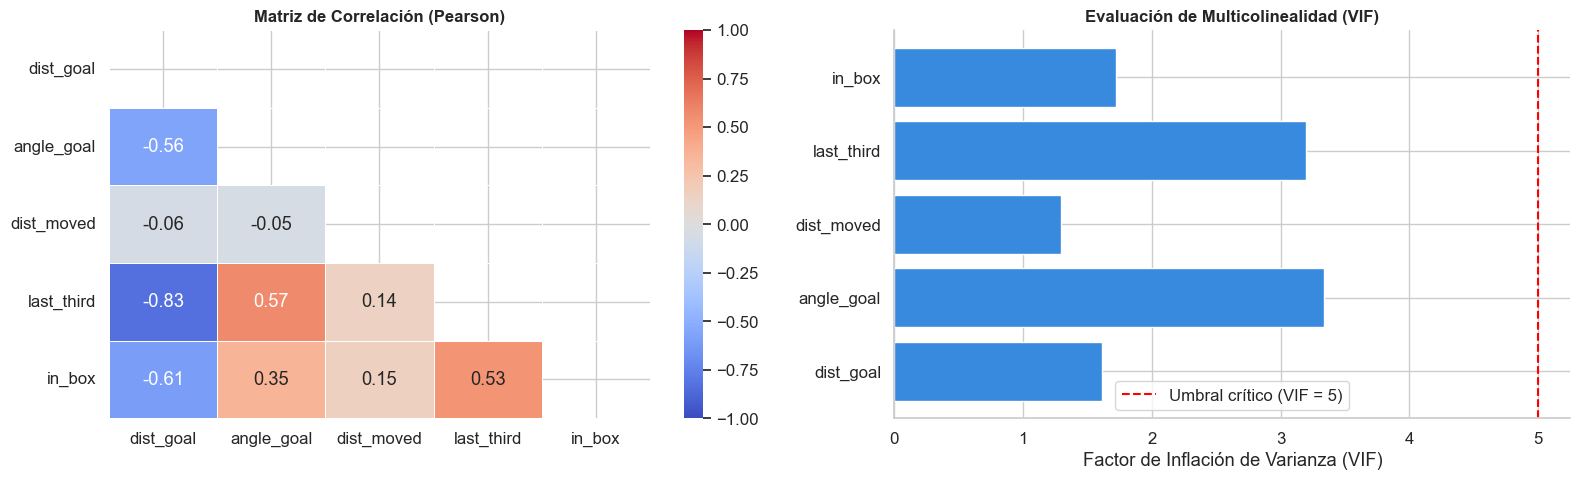

=== TABLA DE MULTICOLINEALIDAD (VIF) ===


,Feature,VIF,Diagnóstico
1,angle_goal,3.3367,Aceptable
3,last_third,3.1964,Aceptable
4,in_box,1.7184,Aceptable
0,dist_goal,1.6100,Aceptable
2,dist_moved,1.2917,Aceptable


In [79]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 1. Matriz de Correlación de Pearson
numeric_features = ['dist_goal', 'angle_goal', 'dist_moved', 'last_third', 'in_box']
numeric_data = df_spadl_fe[numeric_features].dropna()

corr_matrix = numeric_data.corr()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Heatmap
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, 
    mask=mask,
    annot=True, fmt='.2f', 
    cmap='coolwarm', 
    center=0,
    vmin=-1, vmax=1,
    ax=axes[0], linewidths=0.5
)
axes[0].set_title('Matriz de Correlación (Pearson)', fontsize=12, fontweight='bold')

# 2. Análisis formal de Multicolinealidad (VIF)
# Agregamos una constante temporal para calcular VIF correctamente
vif_df = pd.DataFrame()
vif_df['Feature'] = numeric_features
vif_df['VIF'] = [
    variance_inflation_factor(numeric_data.values, i) 
    for i in range(numeric_data.shape[1])
]
vif_df['Diagnóstico'] = vif_df['VIF'].apply(
    lambda x: 'Severa (VIF > 5)' if x >= 5 else 'Aceptable'
)

# Gráfico de barras de VIF
axes[1].barh(vif_df['Feature'], vif_df['VIF'], color=['#e41a1c' if v >= 5 else '#378ADD' for v in vif_df['VIF']])
axes[1].axvline(5.0, color='red', linestyle='--', label='Umbral crítico (VIF = 5)')
axes[1].set_xlabel('Factor de Inflación de Varianza (VIF)')
axes[1].set_title('Evaluación de Multicolinealidad (VIF)', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

print("=== TABLA DE MULTICOLINEALIDAD (VIF) ===")
display(vif_df.sort_values(by='VIF', ascending=False))


> **Interpretación para el modelado posterior (ej. VAEP / xG):**
> * Variables como `dist_goal` y `last_third` presentan una fuerte correlación ($r \approx -0.80$) porque ambas dependen de la proximidad al arco rival.
> * En modelos lineales o regresiones logísticas, alimentar ambas variables al mismo tiempo infla la varianza de los coeficientes y genera inestabilidad.
> * En modelos basados en árboles de decisión (como XGBoost o LightGBM, usados típicamente en VAEP), la multicolinealidad no afecta el poder predictivo, pero sí dificulta la interpretabilidad de la importancia de features (*Feature Importance* o *SHAP values*).


## 5. Normalización por posición y minutos jugados

Las métricas brutas son injustas: un delantero tendrá más tiros que un defensor por posición,
no por calidad. Normalizar por posición y por minutos jugados es esencial.

Para resolver esto aplicamos un pipeline de normalización en dos etapas consecutivas:

### Etapa 1: Normalización Temporal (`_p90`)
Llevamos todas las métricas a una unidad de medida estándar: **tasa de producción por partido completo (90 minutos)**:
$$\text{Métrica}_{p90} = \frac{\text{Métrica Total}}{\text{Minutos Jugados}} \times 90$$
* **¿Cómo se interpreta?** Indica la frecuencia esperada del evento si el jugador disputara los 90 minutos reglamentarios.
* **Muestra mínima:** Se filtran jugadores con pocos minutos (ej. $\ge 450$ min) para evitar distorsiones estadísticas (p. ej. un jugador que jugó 10 minutos e hizo 1 tiro tendría un irreal $9.0\text{ tiros}_{p90}$).


In [69]:
def normalize_per_90(player_stats: pd.DataFrame, 
                     stat_cols: list,
                     minutes_col: str = 'minutes_played') -> pd.DataFrame:
    """
    Normaliza estadísticas crudas a escala por 90 minutos.
    Estándar en el análisis profesional de fútbol.
    """
    df = player_stats.copy()
    for col in stat_cols:
        if col in df.columns:
            df[f'{col}_p90'] = df[col] / (df[minutes_col] / 90)
    return df

# Calculamos estadísticas agregadas por jugador desde SPADL
player_agg = df_spadl_fe.groupby('player_id').agg(
    total_actions=('type_id', 'count'),
    shots=('type_name', lambda x: (x == 'shot').sum()),
    passes=('type_name', lambda x: (x == 'pass').sum()),
    crosses=('type_name', lambda x: (x == 'cross').sum()),
    dribbles=('type_name', lambda x: (x == 'take_on').sum()),
    in_box_actions=('in_box', 'sum'),
    last_third_actions=('last_third', 'sum'),
).reset_index()

# Estimación aproximada de minutos (no disponible directamente en Wyscout)
# Asumimos 90 min por partido; en producción se usaría la API
games_per_player = df_spadl_fe.groupby('player_id')['game_id'].nunique().reset_index()
games_per_player.columns = ['player_id', 'games_played']
player_agg = player_agg.merge(games_per_player, on='player_id')
player_agg['minutes_played'] = player_agg['games_played'] * 75  # promedio realista

# Solo jugadores con suficientes minutos
player_agg = player_agg[player_agg['minutes_played'] >= 450]

# Normalización
stat_cols = ['shots', 'passes', 'crosses', 'dribbles', 'in_box_actions']
player_agg_norm = normalize_per_90(player_agg, stat_cols)

print(f'Jugadores con ≥450 minutos: {len(player_agg_norm)}')
print(player_agg_norm[['player_id','shots_p90','passes_p90','dribbles_p90']].head(10))

Jugadores con ≥450 minutos: 456
    player_id  shots_p90  passes_p90  dribbles_p90
0           0     0.0118      0.1059        0.0000
3         151     1.3920     17.2800        0.1440
4         254     0.4800     50.5714        0.2743
6        1751     1.4400     24.8400        0.0000
7        3267     0.0000     18.8727        0.0000
8        3269     0.5455     75.9636        0.1091
9        3270     0.2483     55.8621        0.0414
10       3277     0.2222     59.2444        0.1778
11       3280     1.1613     78.8903        0.3484
12       3282     1.9333     37.6333        0.1667


### Etapa 2: Normalización Posicional (Comparación entre pares)
Una vez en escala `p90`, comparamos el rendimiento de cada futbolista **únicamente contra sus pares de la misma posición** mediante dos métricas complementarias:
#### A. Puntuación Estándar ($Z\text{-Score}$ Posicional)
Mide a cuántas desviaciones estándar ($\sigma$) se encuentra el jugador respecto a la media ($\mu$) de su misma posición:
$$Z = \frac{X_{p90} - \mu_{\text{posición}}}{\sigma_{\text{posición}}}$$
* **$Z = 0$:** Rendimiento idéntico al promedio de su posición.
* **$Z > +1.0$:** Por encima de la media de su posición (destacado).
* **$Z \ge +2.0$:** En el nivel de élite / outlier positivo dentro de su rol (aprox. top 2.5%).
* **$Z < 0$:** Por debajo del promedio de los futbolistas de su misma posición.
#### B. Rango Percentilar (`_pct` Posicional, 0 a 100)
Indica el porcentaje de jugadores de su misma posición a los que supera en esa métrica (la base de los *radares* y *pizza charts* de StatsBomb/FBref):
* **Percentil 50:** Mediana exacta del puesto.
* **Percentil 90:** El jugador supera al 90% de los futbolistas de su misma posición en esa métrica (top 10%).
> **Conclusión:** Este doble escalado permite descubrir perfiles tácticos reales (por ejemplo: un lateral con un volumen de centros en percentil 95 dentro de los defensores, o un mediocampista con llegada al área en percentil 85 dentro de los volantes).

In [70]:

# Extraemos la posición principal de cada jugador
def get_main_position(role):
    if isinstance(role, dict):
        return role.get('name', 'Unknown')
    return 'Unknown'

df_players_filtrado['main_position'] = df_players_filtrado['role'].apply(get_main_position)

print('Posiciones disponibles:')
print(df_players_filtrado['main_position'].value_counts())

Posiciones disponibles:
main_position
Midfielder    206
Defender      188
Forward       113
Goalkeeper     50
Name: count, dtype: int64


In [71]:
# 1. Unir la posición principal de los jugadores
df_players_pos = df_players_filtrado[['wyId', 'main_position']].rename(columns={'wyId': 'player_id'})
player_agg_norm = player_agg_norm.merge(df_players_pos, on='player_id', how='left')

# 2. Filtrar posiciones desconocidas (opcional pero recomendado)
player_agg_norm = player_agg_norm[player_agg_norm['main_position'] != 'Unknown']

# 3. Lista de métricas p90 a normalizar por posición
p90_cols = ['shots_p90', 'passes_p90', 'crosses_p90', 'dribbles_p90', 'in_box_actions_p90']

# 4. Calcular Z-Score y Percentil por posición para cada métrica
for col in p90_cols:
    # Z-Score por posición: (x - media_pos) / std_pos
    player_agg_norm[f'{col}_zscore'] = player_agg_norm.groupby('main_position')[col].transform(
        lambda x: (x - x.mean()) / (x.std() + 1e-9)
    )
    # Percentil por posición: (0 a 100)
    player_agg_norm[f'{col}_pct'] = player_agg_norm.groupby('main_position')[col].transform(
        lambda x: x.rank(pct=True) * 100
    )

# 5. Visualizar resultados con los nombres de columnas correctos
cols_to_show = ['player_id', 'main_position', 'shots_p90', 'shots_p90_zscore', 'shots_p90_pct']
player_agg_norm[cols_to_show].head(10)


,player_id,main_position,shots_p90,shots_p90_zscore,shots_p90_pct
0,0,NaN,0.0118,NaN,NaN
1,151,Forward,1.3920,-0.2425,42.5743
2,254,Defender,0.4800,0.1694,63.0719
3,1751,Forward,1.4400,-0.1900,47.0297
4,3267,Goalkeeper,0.0000,-0.2583,48.3871
5,3269,Defender,0.5455,0.4105,69.9346
6,3270,Defender,0.2483,-0.6842,28.1046
7,3277,Defender,0.2222,-0.7801,23.5294
8,3280,Midfielder,1.1613,0.4867,74.7059
9,3282,Midfielder,1.9333,1.9413,94.7059


In [73]:
#acciones de Messi
player_agg_norm[player_agg_norm['player_id']==3359][cols_to_show]

,player_id,main_position,shots_p90,shots_p90_zscore,shots_p90_pct
38,3359,Forward,4.7333,3.4157,99.0099


🔍 Interpretación Métrica por Métrica de Messi
1. shots_p90 = 4.73 — Volumen por Partido Reglamentario

- Interpretación: Messi promedia 4.73 tiros por cada 90 minutos jugados (aproximadamente un remate cada 19 minutos de juego).
- Contexto en el fútbol profesional: En las principales ligas europeas, el promedio habitual de un delantero centro ronda entre $2.0$ y $2.8$ tiros por 90 min. Un valor cercano a $5$ tiros por partido representa un volumen ofensivo extraordinario.
2. shots_p90_zscore = +3.42 — El Concepto de Outlier Estadístico
- Interpretación: Messi se encuentra a $3.42$ desviaciones estándar por encima de la media de todos los delanteros de la muestra.
- Rigurosidad estadística: En distribuciones estadísticas estándar, cualquier valor con $Z > 3.0$ se define formalmente como un outlier positivo extremo (la probabilidad teórica de encontrar un valor así al azar es menor al $0.1%$, o menos de 1 en 1.000 casos).
- Lectura futbolística: No solo está "por encima de la media"; su capacidad de generar tiros rompe la campana de distribución de su propia posición.
3. shots_p90_pct = 99.01% — Rango Percentilar dentro de Delanteros
- Interpretación: Messi supera en volumen de remates al $99%$ de los delanteros analizados en el dataset.
- Uso práctico: Este es el valor directo que se utiliza para graficar en los radares de rendimiento (pizza charts o spider charts de StatsBomb/FBref). Messi tendría su barra de volumen de tiros prácticamente al 100% de la escala de delanteros.

🎓 Conclusión

"Si solo hubiéramos mirado la cantidad bruta de tiros, Messi podría haber tenido muchos tiros simplemente por haber jugado todos los partidos. Pero al aplicar el pipeline de dos etapas:

La normalización por 90 minutos demostró que su frecuencia de disparo es altísima ($4.73\text{ p90}$).
La normalización por posición demostró que, aun comparándolo exclusivamente contra otros delanteros (cuyo rol también es rematar), Messi se ubica en el Top 1% ($Z = +3.42$, Percentil 99), confirmando cuantitativamente su condición de jugador generador de peligro de élite mundial."

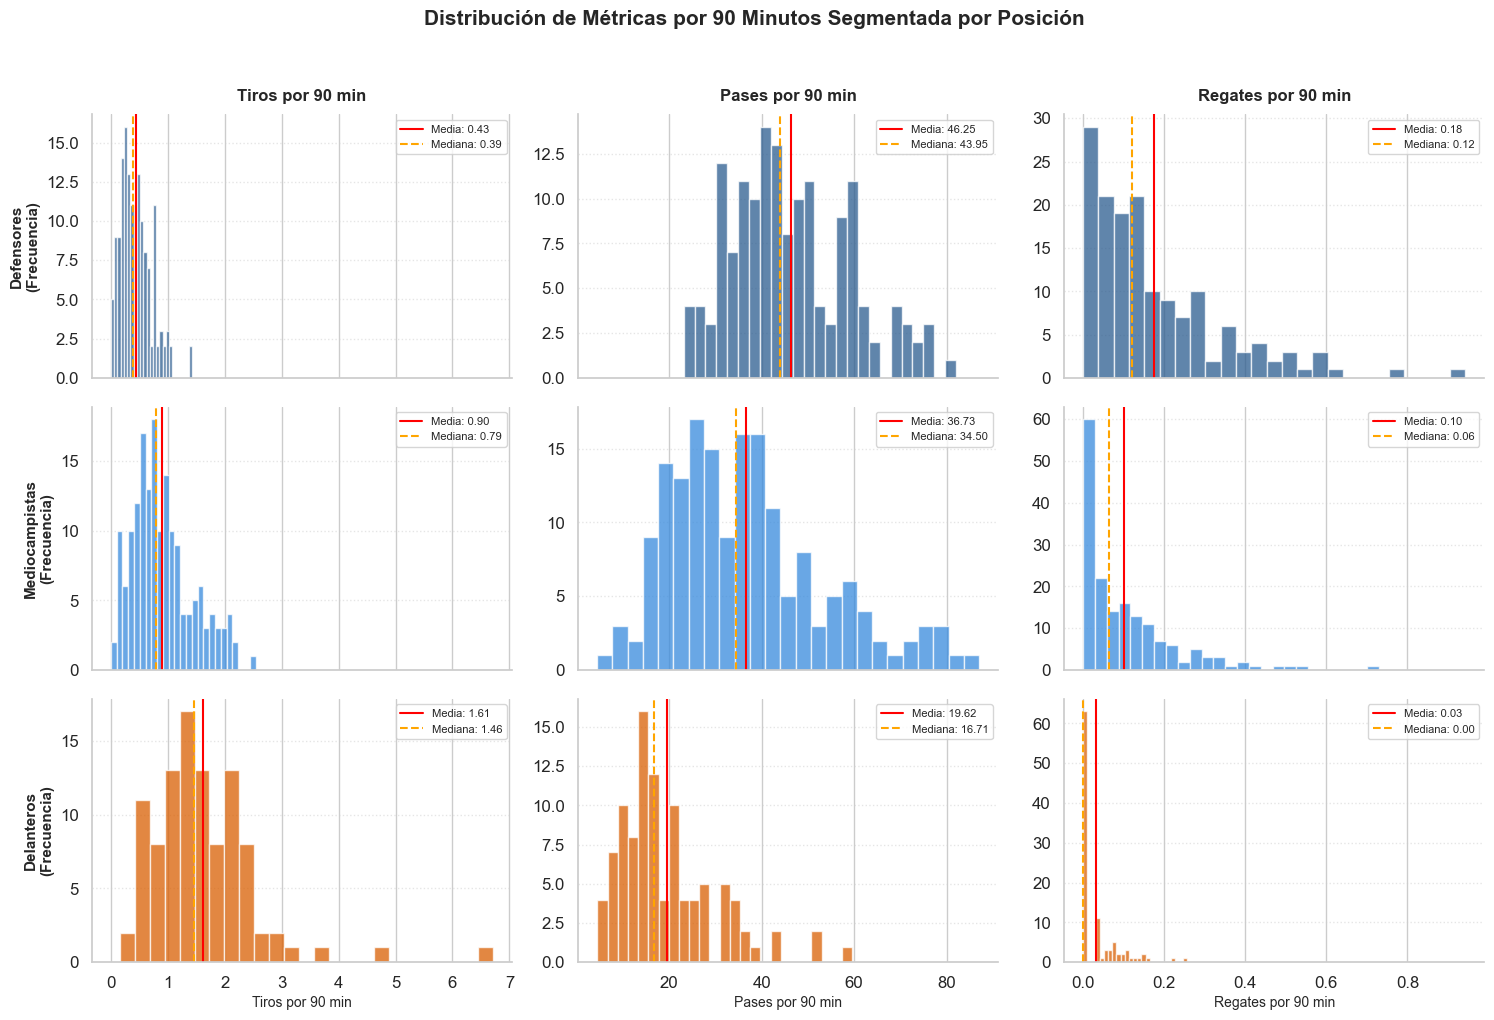

In [74]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Definir posiciones y métricas a comparar
positions = ['Defender', 'Midfielder', 'Forward']
position_labels = ['Defensores', 'Mediocampistas', 'Delanteros']
pos_colors = {'Defender': '#2b5c8f', 'Midfielder': '#378ADD', 'Forward': '#d95f02'}

metrics = [
    ('shots_p90', 'Tiros por 90 min'),
    ('passes_p90', 'Pases por 90 min'),
    ('dribbles_p90', 'Regates por 90 min')
]

# 2. Crear grilla de 3 filas (posiciones) x 3 columnas (métricas)
fig, axes = plt.subplots(len(positions), len(metrics), figsize=(15, 10), sharex='col')

for row_idx, (pos, pos_lbl) in enumerate(zip(positions, position_labels)):
    df_pos = player_agg_norm[player_agg_norm['main_position'] == pos]
    color = pos_colors.get(pos, '#378ADD')
    
    for col_idx, (metric, metric_lbl) in enumerate(metrics):
        ax = axes[row_idx, col_idx]
        data = df_pos[metric].dropna()
        
        # Histograma
        ax.hist(data, bins=25, color=color, edgecolor='white', alpha=0.75)
        
        # Líneas de referencia: Media y Mediana de esa posición
        mean_val = data.mean()
        med_val = data.median()
        ax.axvline(mean_val, color='red', linestyle='-', linewidth=1.5, label=f'Media: {mean_val:.2f}')
        ax.axvline(med_val, color='orange', linestyle='--', linewidth=1.5, label=f'Mediana: {med_val:.2f}')
        
        # Etiquetas y títulos
        if row_idx == 0:
            ax.set_title(f'{metric_lbl}', fontsize=12, fontweight='bold', pad=10)
        if col_idx == 0:
            ax.set_ylabel(f'{pos_lbl}\n(Frecuencia)', fontsize=11, fontweight='bold')
        else:
            ax.set_ylabel('')
            
        if row_idx == len(positions) - 1:
            ax.set_xlabel(metric_lbl, fontsize=10)
            
        ax.legend(fontsize=8, loc='upper right')
        ax.spines[['top', 'right']].set_visible(False)
        ax.grid(axis='y', linestyle=':', alpha=0.5)

plt.suptitle('Distribución de Métricas por 90 Minutos Segmentada por Posición', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


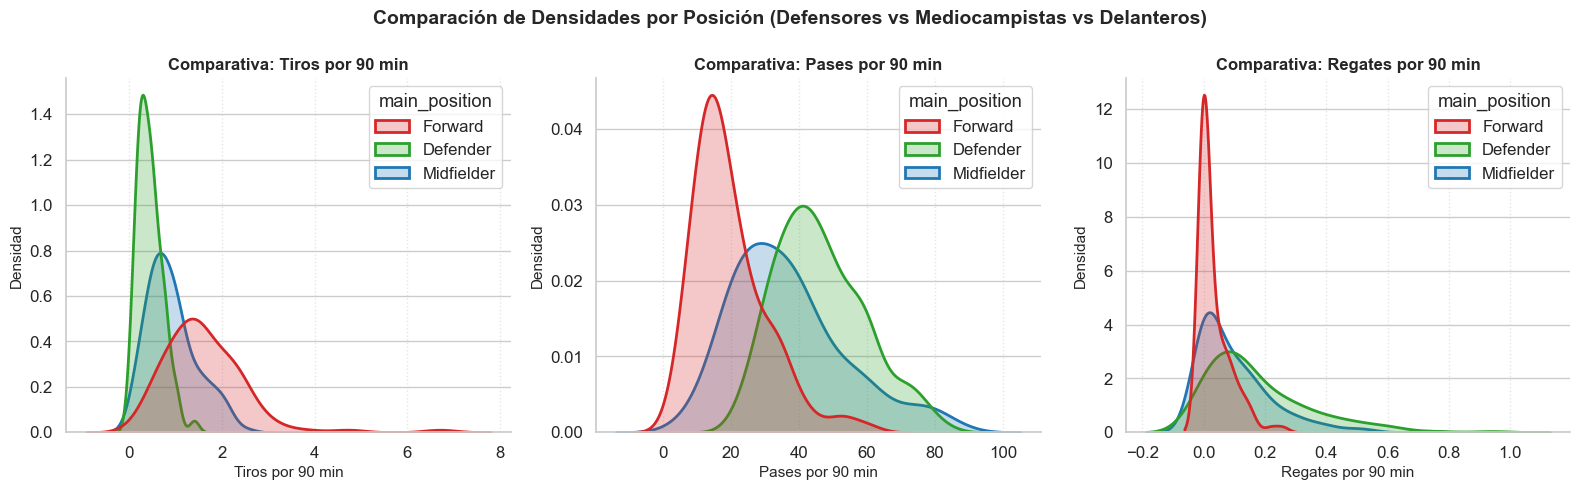

In [75]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

positions = ['Defender', 'Midfielder', 'Forward']
palette = {'Defender': '#2ca02c', 'Midfielder': '#1f77b4', 'Forward': '#d62728'}

for ax, col, label in zip(
    axes, 
    ['shots_p90', 'passes_p90', 'dribbles_p90'],
    ['Tiros por 90 min', 'Pases por 90 min', 'Regates por 90 min']
):
    df_filtered = player_agg_norm[player_agg_norm['main_position'].isin(positions)]
    
    # Gráfico de densidad (KDE) por posición
    sns.kdeplot(
        data=df_filtered,
        x=col,
        hue='main_position',
        palette=palette,
        fill=True,
        alpha=0.25,
        common_norm=False,
        ax=ax,
        linewidth=2
    )
    
    ax.set_xlabel(label, fontsize=11)
    ax.set_ylabel('Densidad', fontsize=11)
    ax.set_title(f'Comparativa: {label}', fontsize=12, fontweight='bold')
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(axis='x', linestyle=':', alpha=0.5)

plt.suptitle('Comparación de Densidades por Posición (Defensores vs Mediocampistas vs Delanteros)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


- Tiros p90: La distribución de los delanteros se desplaza marcadamente hacia la derecha respecto a defensores y mediocampistas.
- Pases p90: Los mediocampistas tienen una media de pases significativamente superior y una campana más ancha.
- Regates p90: Refleja asimetría positiva (skewed right) en todas las posiciones, pero con mayor cola en extremos y delanteros.

## 6. Curación final del dataset

Consolidamos todas las decisiones de limpieza y generamos el dataset final para modelado.

In [80]:
def curate_dataset(df_spadl: pd.DataFrame) -> tuple:
    """
    Pipeline de curación completo del dataset SPADL.
    Retorna (df_clean, report) donde report documenta las decisiones.
    """
    report = {}
    df = df_spadl.copy()
    n_initial = len(df)
    report['n_initial'] = n_initial

    # 1. Remover acciones con coordenadas inválidas
    df = df.dropna(subset=['start_x', 'start_y'])
    report['removed_missing_coords'] = n_initial - len(df)

    # 2. Remover coordenadas fuera de rango
    valid_coords = (
        (df['start_x'].between(0, 105)) & 
        (df['start_y'].between(0, 68))
    )
    df = df[valid_coords]
    report['removed_out_of_bounds'] = (n_initial - report['removed_missing_coords']) - len(df)

    # 3. Remover acciones duplicadas (mismo game, time, player, type)
    dup_mask = df.duplicated(subset=['game_id', 'period_id', 'time_seconds', 'player_id', 'type_id'])
    report['removed_duplicates'] = dup_mask.sum()
    df = df[~dup_mask]

    # 4. Estandarizar el tipo 'bad_touch' (varía entre ligas en Wyscout)
    # Mantenemos pero lo documentamos
    report['bad_touch_actions'] = (df['type_name'] == 'bad_touch').sum()

    # 5. Verificación de integridad temporal
    df = df.sort_values(['game_id', 'period_id', 'time_seconds'])
    # Detectar saltos de tiempo imposibles
    df['time_delta'] = df.groupby(['game_id', 'period_id'])['time_seconds'].diff()
    impossible_time = df['time_delta'] < 0
    report['time_ordering_issues'] = impossible_time.sum()
    df = df[~impossible_time]

    report['n_final'] = len(df)
    report['removal_pct'] = (n_initial - len(df)) / n_initial * 100

    return df, report

df_clean, curation_report = curate_dataset(df_spadl_fe)

print('=== REPORTE DE CURACIÓN DE DATOS ===')
for k, v in curation_report.items():
    print(f'  {k}: {v:,}' if isinstance(v, int) else f'  {k}: {v:.2f}')

=== REPORTE DE CURACIÓN DE DATOS ===
  n_initial: 357,443
  removed_missing_coords: 191
  removed_out_of_bounds: 0
  removed_duplicates: 5.00
  bad_touch_actions: 0.00
  time_ordering_issues: 0.00
  n_final: 357,247
  removal_pct: 0.05


In [51]:
# Guardar el dataset curado para el Práctico 3
output_path = './spadl_curado_PL_2017.parquet'
df_clean.to_parquet(output_path, index=False)
print(f'Dataset guardado en: {output_path}')
print(f'Shape final: {df_clean.shape}')
print(f'Tamaño: {os.path.getsize(output_path)/1e6:.1f} MB')

Dataset guardado en: ./spadl_curado_PL_2017.parquet
Shape final: (357247, 18)
Tamaño: 8.6 MB


## 7. Actividades propuestas

### Ejercicio 1 — Auditoría de calidad multilga
Compará la tasa de eventos con coordenadas válidas entre las 5 ligas europeas.
¿Hay diferencias en la calidad de los datos? ¿Qué ligas parecen tener mejor cobertura?
Realizá un test estadístico (chi-cuadrado) para determinar si las diferencias son significativas.

### Ejercicio 2 — Análisis de la distribución temporal
Graficá la intensidad de eventos (acciones por minuto) a lo largo de un partido tipo.
Identificá los momentos con mayor actividad. ¿Hay un patrón antes y después del gol?
Sugerencia: calculá la densidad de eventos en ventanas de 5 minutos.

### Ejercicio 3 — Feature engineering avanzado
Implementá las siguientes features adicionales:
- `shot_zone`: zona del área desde donde se realizó el tiro (6 zonas estándar)
- `pressing_intensity`: número de duelos en los últimos 30 segundos
- `build_up_length`: longitud de la secuencia de pases antes de un tiro

### Ejercicio 4 — Sesgo posicional
Analizá si el número de acciones en SPADL está sesgado por posición.
¿Los delanteros tienen más acciones en el último tercio? ¿Los mediocampistas hacen más pases?
Graficá boxplots de las principales métricas por posición.

### Ejercicio 5 — Decisiones de curación
Basándote en el análisis anterior, documentá en un reporte las 5 decisiones más importantes
de curación para este dataset. Para cada decisión: ¿qué problema resolvió? ¿cuántos registros
afectó? ¿qué alternativas consideraste?

---
### **Entregable 4/9/26**: Notebook con EDA completo + reporte de decisiones de curación. PPT con donde se muestren los principales hallazgos encontrados en esos dos TPs.